# Лабораторная работа: Регрессия в машинном обучении
**Выполнили:** Медведь Е.Ю. ИСУ 368509
**Дисциплина:** Методы искусственного интеллекта    
**Тема:** Регрессионный анализ на датасете *California Housing* (scikit-learn)


## 0. Импорт библиотек и настройка окружения

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Часть 1. Загрузка и анализ данных
### 1.1 Загрузка датасета California Housing

In [ ]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()
df.rename(columns={"MedHouseVal": "target"}, inplace=True)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 1.2 Основная информация о данных (размерность, типы, статистики)

In [ ]:
print("Размерность (строки, признаки+таргет):", df.shape)
display(df.info())
df.describe().T

Размерность (строки, признаки+таргет): (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


None

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
target,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### 1.3 Проверка пропусков

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0


**Вывод:** в исходном датасете California Housing пропуски отсутствуют (по результату проверки выше).

### 1.4 Визуализация распределения целевой переменной (медианная стоимость жилья)

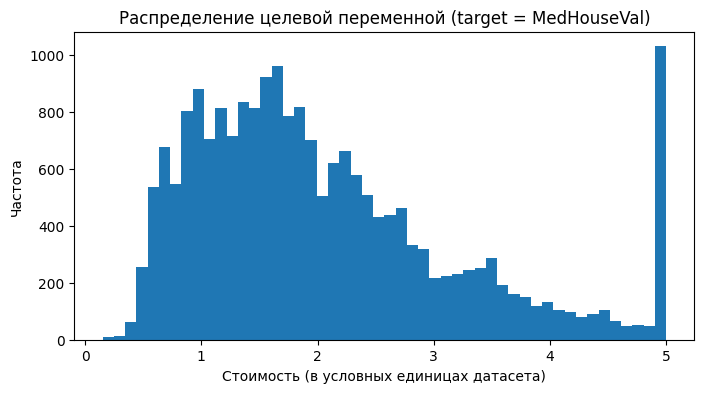

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df["target"], bins=50)
plt.title("Распределение целевой переменной (target = MedHouseVal)")
plt.xlabel("Стоимость (в условных единицах датасета)")
plt.ylabel("Частота")
plt.show()

### 1.5 Корреляционная матрица признаков и целевой переменной

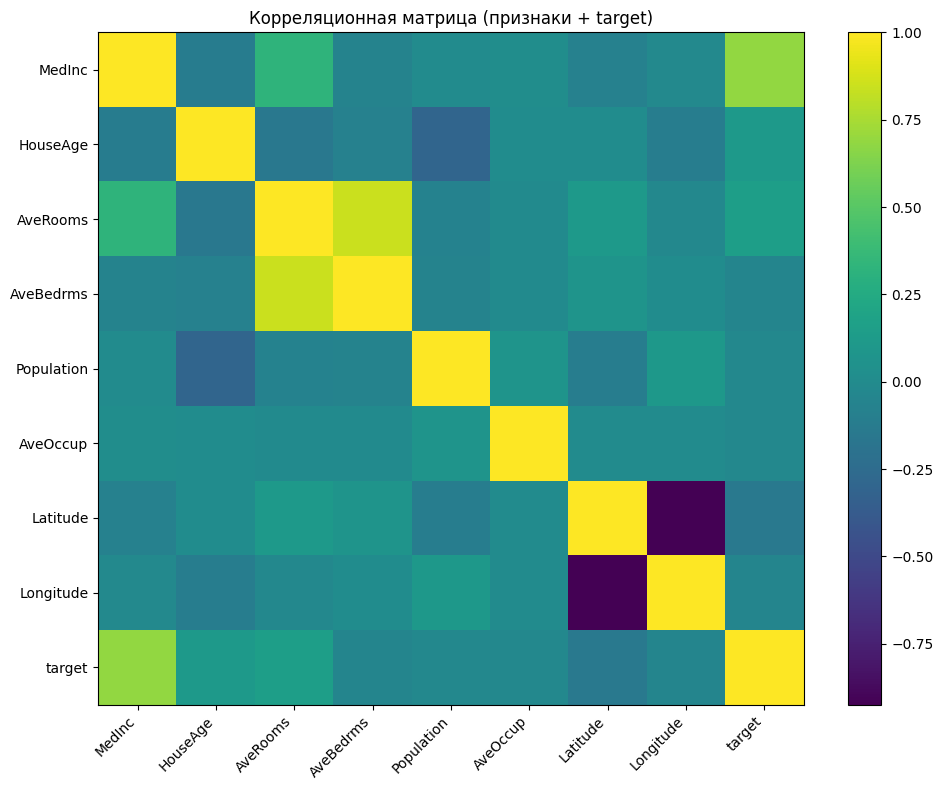

,target
target,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Корреляционная матрица (признаки + target)")
plt.tight_layout()
plt.show()

# Отдельно: корреляции признаков с целевой переменной
corr_target = corr["target"].sort_values(ascending=False)
corr_target

## Часть 2. Предварительная обработка и feature engineering
По условию нужно создать **2–3 новых признака** на основе существующих. Для California Housing доступны агрегированные характеристики района (например, среднее число комнат, средняя заселенность и т.п.), поэтому удобно строить **отношения и «интенсивности»**.

### 2.1 Создание новых признаков
Создадим 3 признака:
1. **rooms_per_occupant** = AveRooms / AveOccup — сколько комнат приходится на одного жителя (характеристика плотности/комфорта).  
2. **bedrooms_share** = AveBedrms / AveRooms — доля спален среди всех комнат (характеристика структуры жилья).  
3. **income_per_occupant** = MedInc / AveOccup — доход на одного жителя (характеристика покупательной способности с учетом плотности населения).

In [ ]:
df_fe = df.copy()

eps = 1e-9
df_fe["rooms_per_occupant"] = df_fe["AveRooms"] / (df_fe["AveOccup"] + eps)
df_fe["bedrooms_share"] = df_fe["AveBedrms"] / (df_fe["AveRooms"] + eps)
df_fe["income_per_occupant"] = df_fe["MedInc"] / (df_fe["AveOccup"] + eps)

df_fe[["AveRooms","AveOccup","rooms_per_occupant","AveBedrms","bedrooms_share","MedInc","income_per_occupant","target"]].head()

,AveRooms,AveOccup,rooms_per_occupant,AveBedrms,bedrooms_share,MedInc,income_per_occupant,target
0,6.984127,2.555556,2.732919,1.023810,0.146591,8.3252,3.257687,4.526
1,6.238137,2.109842,2.956685,0.971880,0.155797,8.3014,3.934608,3.585
2,8.288136,2.802260,2.957661,1.073446,0.129516,7.2574,2.589838,3.521
3,5.817352,2.547945,2.283154,1.073059,0.184458,5.6431,2.214765,3.413
4,6.281853,2.181467,2.879646,1.081081,0.172096,3.8462,1.763125,3.422


### 2.2 Разделение на обучающую и тестовую выборки (80/20)

In [ ]:
X = df_fe.drop(columns=["target"])
y = df_fe["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (16512, 11) Test: (4128, 11)


### 2.3 Стандартизация признаков
Для линейных моделей (Linear Regression, Ridge) стандартизация обычно полезна: признаки приводятся к единому масштабу.  
Для деревьев (Random Forest, XGBoost) масштабирование не критично, но мы будем делать масштабирование внутри пайплайна только для линейных моделей, чтобы не мешать деревьям.

## Часть 3. Построение моделей и оценка качества
Будем сравнивать модели по метрикам: MSE, RMSE, MAE, R² на тестовой выборке.

Ниже — вспомогательные функции для оценки.

In [ ]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = regression_metrics(y_test, pred)
    return name, model, pred, metrics

### 3.1 Линейная регрессия (baseline)

In [ ]:
linreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

name_lr, model_lr, pred_lr, metrics_lr = evaluate_model(
    "LinearRegression", linreg, X_train, y_train, X_test, y_test
)
metrics_lr

{'MSE': 0.438409015852293,
 'RMSE': 0.6621246225993208,
 'MAE': 0.47382970699605303,
 'R2': 0.6654410774559743}

### 3.2 Ridge регрессия с подбором коэффициента регуляризации α
Используем `GridSearchCV` по сетке значений `alpha`.

In [ ]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(random_state=RANDOM_STATE))
])

ridge_param_grid = {
    "model__alpha": np.logspace(-3, 3, 13)  # от 1e-3 до 1e3
}

ridge_search = GridSearchCV(
    ridge_pipe,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

print("Лучший alpha:", ridge_search.best_params_)
print("CV RMSE:", -ridge_search.best_score_)

best_ridge = ridge_search.best_estimator_
pred_ridge = best_ridge.predict(X_test)
metrics_ridge = regression_metrics(y_test, pred_ridge)
metrics_ridge

Лучший alpha: {'model__alpha': np.float64(10.0)}
CV RMSE: 0.6556786636695617


{'MSE': 0.4384779587936357,
 'RMSE': 0.6621766824599276,
 'MAE': 0.4738096501263454,
 'R2': 0.665388465681721}

### 3.3 Random Forest с подбором гиперпараметров
Для Random Forest используем `RandomizedSearchCV`.

In [ ]:
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

rf_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train)

print("Лучшие параметры RF:", rf_search.best_params_)
print("CV RMSE:", -rf_search.best_score_)

best_rf = rf_search.best_estimator_
pred_rf = best_rf.predict(X_test)
metrics_rf = regression_metrics(y_test, pred_rf)
metrics_rf

Лучшие параметры RF: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
CV RMSE: 0.5175126660452121


{'MSE': 0.26799897658922933,
 'RMSE': 0.5176861757756618,
 'MAE': 0.3435237822744703,
 'R2': 0.795484477717031}

### 3.4 Градиентный бустинг: XGBoost
XGBoost — один из наиболее сильных градиентных бустингов на деревьях. Подберём ключевые параметры через `RandomizedSearchCV`.

In [ ]:
xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    n_estimators=800,
    learning_rate=0.05,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1
)

xgb_param_dist = {
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0.0, 1e-3, 1e-2, 1e-1],
    "reg_lambda": [1.0, 2.0, 5.0],
    "gamma": [0.0, 0.1, 0.2]
}

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE
)

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=3,  # из-за тяжёлой модели уменьшим CV для подбора
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

xgb_search.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Лучшие параметры XGB:", xgb_search.best_params_)
print("CV RMSE:", -xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_
pred_xgb = best_xgb.predict(X_test)
metrics_xgb = regression_metrics(y_test, pred_xgb)
metrics_xgb

Лучшие параметры XGB: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.01, 'min_child_weight': 5, 'max_depth': 6, 'gamma': 0.0, 'colsample_bytree': 0.8}
CV RMSE: 0.45589768426198485


{'MSE': 0.19423137051104128,
 'RMSE': 0.4407168824892476,
 'MAE': 0.2879514639809266,
 'R2': 0.8517780527024635}

## Часть 4. Анализ результатов
### 4.1 Сравнение моделей по метрикам качества

In [ ]:
results = pd.DataFrame([
    {"Model": "LinearRegression", **metrics_lr},
    {"Model": "Ridge", **metrics_ridge},
    {"Model": "RandomForest", **metrics_rf},
    {"Model": "XGBoost", **metrics_xgb},
]).set_index("Model").sort_values("RMSE")

results

,MSE,RMSE,MAE,R2
Model,,,,
XGBoost,0.194231,0.440717,0.287951,0.851778
RandomForest,0.267999,0.517686,0.343524,0.795484
LinearRegression,0.438409,0.662125,0.473830,0.665441
Ridge,0.438478,0.662177,0.473810,0.665388


Построим простой график сравнения по RMSE (чем ниже — тем лучше).

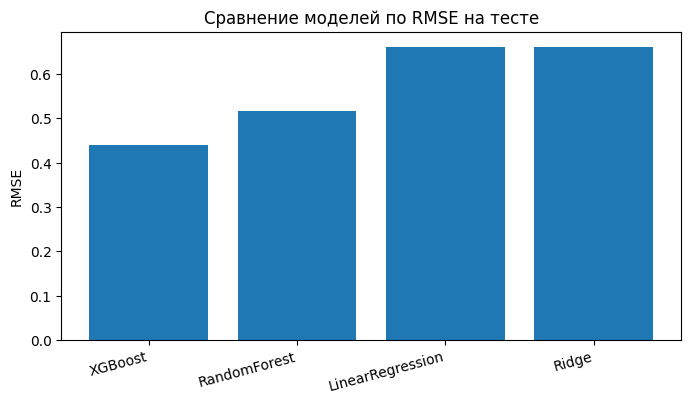

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(results.index, results["RMSE"])
plt.title("Сравнение моделей по RMSE на тесте")
plt.ylabel("RMSE")
plt.xticks(rotation=15, ha="right")
plt.show()

### 4.2 Лучшая модель: predicted vs real
Определим лучшую модель по минимальному RMSE и построим scatter-график `y_pred` vs `y_true`.

In [ ]:
best_model_name = results.index[0]
best_model_name

'XGBoost'

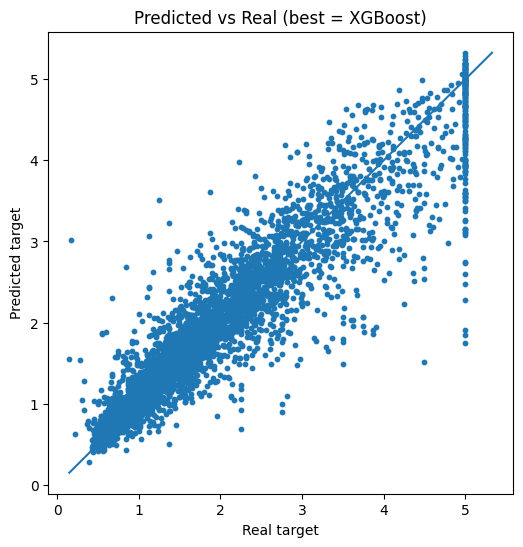

In [ ]:
pred_map = {
    "LinearRegression": pred_lr,
    "Ridge": pred_ridge,
    "RandomForest": pred_rf,
    "XGBoost": pred_xgb
}

best_pred = pred_map[best_model_name]

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_pred, s=10)
plt.title(f"Predicted vs Real (best = {best_model_name})")
plt.xlabel("Real target")
plt.ylabel("Predicted target")

# Диагональ y=x
mmin = float(min(y_test.min(), best_pred.min()))
mmax = float(max(y_test.max(), best_pred.max()))
plt.plot([mmin, mmax], [mmin, mmax])
plt.show()

### 4.3 Важность признаков (feature importance) для моделей на деревьях
Рассмотрим важность признаков для RandomForest и XGBoost (если они поддерживают `feature_importances_`).

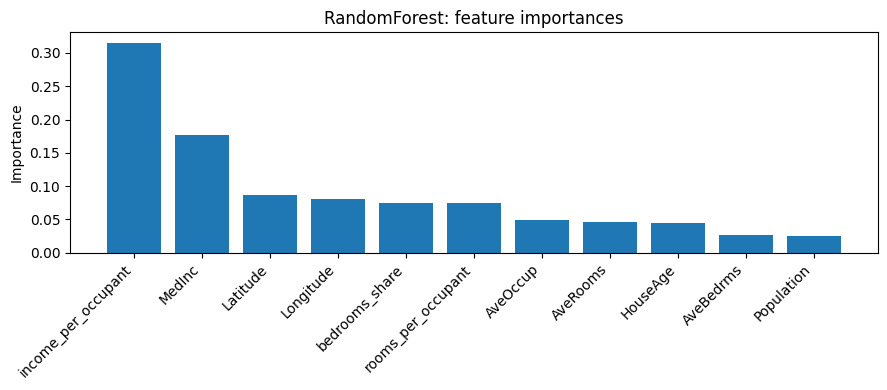

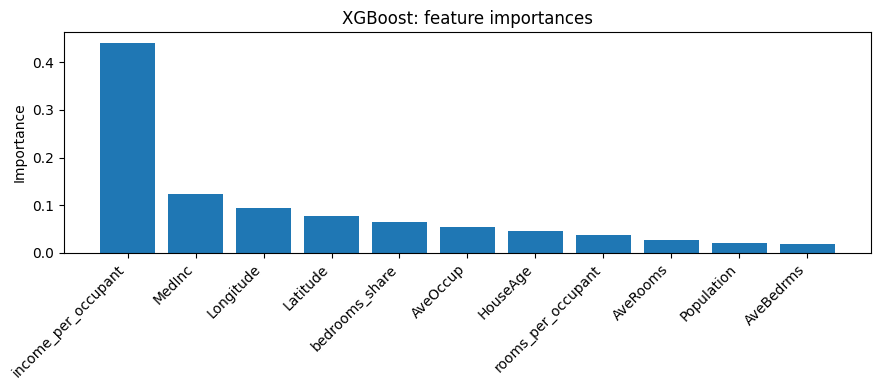

In [ ]:
feature_names = X.columns.tolist()

def plot_feature_importance(importances, title, top_n=15):
    imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(9,4))
    plt.bar(imp.index, imp.values)
    plt.title(title)
    plt.ylabel("Importance")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return imp

if hasattr(best_rf, "feature_importances_"):
    imp_rf = plot_feature_importance(best_rf.feature_importances_, "RandomForest: feature importances", top_n=15)

if hasattr(best_xgb, "feature_importances_"):
    imp_xgb = plot_feature_importance(best_xgb.feature_importances_, "XGBoost: feature importances", top_n=15)

### 4.4 Кросс-валидация (5-fold) для лучшей модели
Сделаем 5-fold CV на полных обучающих данных (train), чтобы оценка была устойчивее.

In [ ]:
# Выбираем объект модели по имени
model_map = {
    "LinearRegression": model_lr,
    "Ridge": best_ridge,
    "RandomForest": best_rf,
    "XGBoost": best_xgb
}
best_model = model_map[best_model_name]

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_validate(
    best_model,
    X_train, y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

cv_report = pd.DataFrame({
    "RMSE": -cv_scores["test_rmse"],
    "MAE": -cv_scores["test_mae"],
    "R2": cv_scores["test_r2"]
})
cv_report

,RMSE,MAE,R2
0,0.463323,0.302387,0.844442
1,0.447023,0.291136,0.849563
2,0.446576,0.293516,0.850456
3,0.456691,0.288569,0.845179
4,0.436834,0.286265,0.852520


In [ ]:
cv_report.agg(["mean", "std"])

,RMSE,MAE,R2
mean,0.450089,0.292375,0.848432
std,0.010200,0.006223,0.003485


## Выводы
1. **Baseline (Linear Regression)** даёт базовый уровень качества, но ограничен линейностью зависимости и чувствителен к масштабам признаков.  
2. **Ridge** обычно улучшает устойчивость линейной модели за счёт регуляризации (особенно при коррелирующих признаках).  
3. **Random Forest** лучше ловит нелинейности и взаимодействия признаков, но может уступать бустингам по качеству и требовать подбора параметров.  
4. **XGBoost** (градиентный бустинг на деревьях) часто показывает лучший результат, т.к. итеративно исправляет ошибки и хорошо моделирует сложные зависимости.

По результатам сравнения метрик (таблица выше) лучшей оказалась модель **с минимальным RMSE**; для неё построены график `predicted vs real`, выполнен анализ важности признаков и проведена **5-fold кросс-валидация**.